In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded successfully")

Libraries loaded successfully


In [9]:
import requests

def get_sp500_tickers():
    """
    Scrape S&P 500 constituents from Wikipedia.
    Returns a list of ticker symbols.
    """
    url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
    
    # simulate a browser to avoid error 403
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}
    
    response = requests.get(url, headers=headers)
    table = pd.read_html(response.text)[0]
    tickers = table['Symbol'].tolist()
    
    # Yahoo Finance uses '-' instead of '.' (es. BRK.B → BRK-B)
    tickers = [t.replace('.', '-') for t in tickers]
    
    print(f"Tickers found: {len(tickers)}")
    return tickers, table

tickers, sp500_table = get_sp500_tickers()
sp500_table[['Symbol', 'Security', 'GICS Sector']].head(10)

Tickers found: 503


,Symbol,Security,GICS Sector
0,MMM,3M,Industrials
1,AOS,A. O. Smith,Industrials
2,ABT,Abbott Laboratories,Health Care
3,ABBV,AbbVie,Health Care
4,ACN,Accenture,Information Technology
5,ADBE,Adobe Inc.,Information Technology
6,AMD,Advanced Micro Devices,Information Technology
7,AES,AES Corporation,Utilities
8,AFL,Aflac,Financials
9,A,Agilent Technologies,Health Care


In [11]:
def download_prices(tickers, start="2010-01-01", end="2024-12-31"):
    """
    Download adjusted closing prices for all tickers.
    Uses yfinance batch download for efficiency.
    """
    print(f"Downloading prices for {len(tickers)} tickers...")
    
    raw = yf.download(
        tickers,
        start=start,
        end=end,
        auto_adjust=True,   # prices are already adjusted
        progress=True
    )
    
    # Teniamo solo il Close price
    prices = raw['Close']
    
    print(f"\nShape: {prices.shape}")
    print(f"Date range: {prices.index[0].date()} → {prices.index[-1].date()}")
    print(f"Tickers downloaded: {prices.shape[1]}")
    
    return prices

prices = download_prices(tickers)

[*****                 10%                       ]  52 of 503 completed$Q: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1735621200")
[**********************49%                       ]  248 of 503 completed$SNDK: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1735621200")
[*********************100%***********************]  503 of 503 completed

4 Failed downloads:
['Q', 'SNDK']: possibly delisted; no price data found  (1d 2010-01-01 -> 2024-12-31) (Yahoo error = "Data doesn't exist for startDate = 1262322000, endDate = 1735621200")
['FOXA', 'ROK']: TypeError("'NoneType' object is not subscriptable")



Shape: (3773, 503)
Date range: 2010-01-04 → 2024-12-30
Tickers downloaded: 503


=== Data Quality Report ===
Total tickers: 503
Complete tickers (0% missing): 422
Tickers with >50% missing data: 28

Missing data distribution:
count    503.0
mean       6.6
std       19.2
min        0.0
25%        0.0
50%        0.0
75%        0.0
max      100.0
dtype: float64


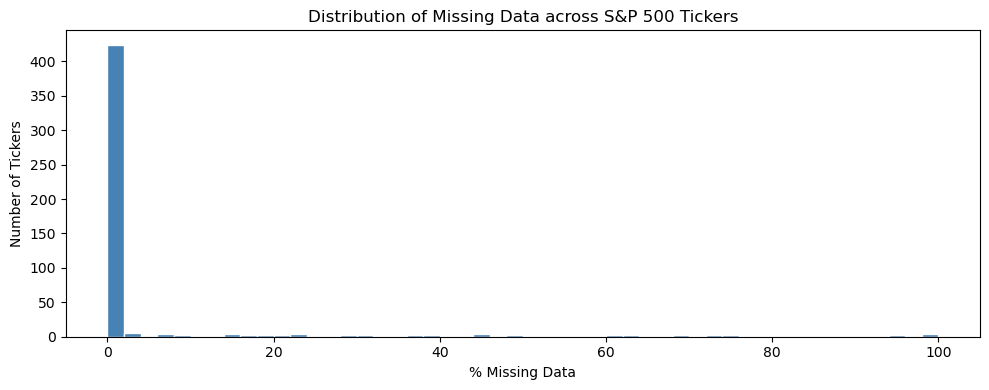

In [15]:
# How many data is missing?
missing_pct = prices.isnull().mean() * 100

print("=== Data Quality Report ===")
print(f"Total tickers: {prices.shape[1]}")
print(f"Complete tickers (0% missing): {(missing_pct == 0).sum()}")
print(f"Tickers with >50% missing data: {(missing_pct > 50).sum()}")
print(f"\nMissing data distribution:")
print(missing_pct.describe().round(2))

# Visualize the distribution of the missing data
plt.figure(figsize=(10, 4))
plt.hist(missing_pct, bins=50, color='steelblue', edgecolor='white')
plt.xlabel('% Missing Data')
plt.ylabel('Number of Tickers')
plt.title('Distribution of Missing Data across S&P 500 Tickers')
plt.tight_layout()
plt.show()

In [21]:
# 1. Calculate daily returns
returns = prices.pct_change()

# 2. Identify extreme returns (>100% or <-50% in a single day)
extreme_returns = (returns.abs() > 1.0)
tickers_with_spikes = extreme_returns.any()
print(f"Tickers with extreme returns (>100% in one day): {tickers_with_spikes.sum()}")
print(tickers_with_spikes[tickers_with_spikes].index.tolist())

# 3. Check for zero or negative prices
zero_prices = (prices <= 0).any()
print(f"\nTickers with zero or negative prices: {zero_prices.sum()}")

# 4. Check the length of available history for each ticker
history_length = prices.notna().sum()
short_history = history_length[history_length < 252]  # less than 1 year of data
print(f"\nTickers with less than 1 year of history: {len(short_history)}")
print(short_history.sort_values())

Tickers with extreme returns (>100% in one day): 0
[]

Tickers with zero or negative prices: 0

Tickers with less than 1 year of history: 6
Ticker
FOXA      0
Q         0
ROK       0
SNDK      0
GEV     192
SOLV    193
dtype: int64


In [23]:
def clean_prices(prices, max_missing_pct=20, min_history_days=252):
    """
    Remove tickers with:
    - Too much missing data
    - Insufficient price history (less than 1 year)
    """
    # Remove tickers with too much missing data
    missing_pct = prices.isnull().mean() * 100
    valid_by_missing = missing_pct[missing_pct <= max_missing_pct].index

    # Remove tickers with insufficient history
    history_length = prices.notna().sum()
    valid_by_history = history_length[history_length >= min_history_days].index

    # Intersection: tickers valid for both criteria
    valid_tickers = valid_by_missing.intersection(valid_by_history)
    prices_clean = prices[valid_tickers].copy()

    print(f"Tickers before cleaning:         {prices.shape[1]}")
    print(f"Removed due to missing data:     {prices.shape[1] - len(valid_by_missing)}")
    print(f"Removed due to short history:    {prices.shape[1] - len(valid_by_history)}")
    print(f"Tickers after cleaning:          {prices_clean.shape[1]}")
    
    return prices_clean

prices_clean = clean_prices(prices)

# Save locally
prices_clean.to_parquet('../data/sp500_prices.parquet')
print("\nData saved to data/sp500_prices.parquet")

Tickers before cleaning:         503
Removed due to missing data:     55
Removed due to short history:    6
Tickers after cleaning:          448

Data saved to data/sp500_prices.parquet
